<a href="https://colab.research.google.com/github/Dilshan-Pasindu/Machine-Learning--Lab/blob/main/IT24101554_ML_Lab_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import seaborn as sns

df = sns.load_dataset("titanic")

In [5]:
print(df.shape)
print(df.info())
print(df.dtypes)

(891, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None
survived          int64
pclass            int64
sex             

- Numerical features -

pclass,
age,
sibsp,
parch,
fare

- Categorical features -

sex,
embarked,
who,
embarked_town,
alive,
alone,
deck,
class,
adult_male

- Target Variable -

survived



In [6]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [7]:
# Count duplicate records
print("Number of duplicate records:", df.duplicated().sum())

Number of duplicate records: 107


In [8]:
# Remove duplicate records
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (784, 15)


In [9]:
missing = df.isnull().sum()

print("Features containing missing values:")
print(missing[missing > 0])

Features containing missing values:
age            106
embarked         2
deck           582
embark_town      2
dtype: int64


- age -

Use median imputation.

Why?

Age is numerical, and the median is less affected by extreme values than the mean

- embarked -

Use mode imputation because it is categorical.

- embark_town -

Also categorical.Mode Imputation.

- deck -

Mode can be used.But this contains large no of missing values.therefor dropping this kinda columns will be more effective

In [10]:
# Make a copy
df_clean = df.copy()

# Display missing values before imputation
print("Missing values BEFORE imputation:")
print(df_clean.isnull().sum())

# Numerical columns
numeric_columns = df_clean.select_dtypes(
    include=["int64", "float64"]
).columns

# Fill numerical missing values with median
for col in numeric_columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Categorical columns
categorical_columns = df_clean.select_dtypes(
    include=["object", "category", "bool"]
).columns

# Fill categorical missing values with mode
for col in categorical_columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(
            df_clean[col].mode()[0]
        )

# Display missing values after imputation
print("\nMissing values AFTER imputation:")
print(df_clean.isnull().sum())

Missing values BEFORE imputation:
survived         0
pclass           0
sex              0
age            106
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           582
embark_town      2
alive            0
alone            0
dtype: int64

Missing values AFTER imputation:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64


- Binary Categorical Features -

sex,
adult_male,
alone,
alive

- Nominal categorical features -

embarked
embark_town
who
deck

- Ordinal categorical features -

class

In [11]:
df_encoded = df_clean.copy()

# Binary encoding
df_encoded["sex"] = df_encoded["sex"].map({
    "male": 0,
    "female": 1
})

df_encoded["alive"] = df_encoded["alive"].map({
    "no": 0,
    "yes": 1
})

df_encoded["adult_male"] = df_encoded["adult_male"].astype(int)

df_encoded["alone"] = df_encoded["alone"].astype(int)

print(df_encoded.head())

   survived  pclass  sex   age  sibsp  parch     fare embarked  class    who  \
0         0       3    0  22.0      1      0   7.2500        S  Third    man   
1         1       1    1  38.0      1      0  71.2833        C  First  woman   
2         1       3    1  26.0      0      0   7.9250        S  Third  woman   
3         1       1    1  35.0      1      0  53.1000        S  First  woman   
4         0       3    0  35.0      0      0   8.0500        S  Third    man   

   adult_male deck  embark_town  alive  alone  
0           1    C  Southampton      0      0  
1           0    C    Cherbourg      1      0  
2           0    C  Southampton      1      1  
3           0    C  Southampton      1      0  
4           1    C  Southampton      0      1  


In [12]:
import pandas as pd

df_onehot = pd.get_dummies(
    df_clean,
    columns=["embarked", "embark_town", "who", "deck"],
    drop_first=False
)

print(df_onehot.head())

   survived  pclass     sex   age  sibsp  parch     fare  class  adult_male  \
0         0       3    male  22.0      1      0   7.2500  Third        True   
1         1       1  female  38.0      1      0  71.2833  First       False   
2         1       3  female  26.0      0      0   7.9250  Third       False   
3         1       1  female  35.0      1      0  53.1000  First       False   
4         0       3    male  35.0      0      0   8.0500  Third        True   

  alive  ...  who_child  who_man  who_woman  deck_A  deck_B  deck_C  deck_D  \
0    no  ...      False     True      False   False   False    True   False   
1   yes  ...      False    False       True   False   False    True   False   
2   yes  ...      False    False       True   False   False    True   False   
3   yes  ...      False    False       True   False   False    True   False   
4    no  ...      False     True      False   False   False    True   False   

   deck_E  deck_F  deck_G  
0   False   False   Fa

In [13]:
# Display only the newly created one-hot encoded columns

encoded_columns = [
    col for col in df_onehot.columns
    if col.startswith("embarked_")
    or col.startswith("embark_town_")
    or col.startswith("who_")
    or col.startswith("deck_")
]

print("\nOne-Hot Encoded Features:")
print(df_onehot[encoded_columns].head())


One-Hot Encoded Features:
   embarked_C  embarked_Q  embarked_S  embark_town_Cherbourg  \
0       False       False        True                  False   
1        True       False       False                   True   
2       False       False        True                  False   
3       False       False        True                  False   
4       False       False        True                  False   

   embark_town_Queenstown  embark_town_Southampton  who_child  who_man  \
0                   False                     True      False     True   
1                   False                    False      False    False   
2                   False                     True      False    False   
3                   False                     True      False    False   
4                   False                     True      False     True   

   who_woman  deck_A  deck_B  deck_C  deck_D  deck_E  deck_F  deck_G  
0      False   False   False    True   False   False   False   False  
1

In [14]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder(
    categories=[["First", "Second", "Third"]]
)

df_clean["class_encoded"] = ordinal_encoder.fit_transform(
    df_clean[["class"]]
)

print(df_clean[["class", "class_encoded"]].head())

   class  class_encoded
0  Third            2.0
1  First            0.0
2  Third            2.0
3  First            0.0
4  Third            2.0


In [15]:
from sklearn.preprocessing import StandardScaler

numeric_features = ["age", "sibsp", "parch", "fare"]

standard_scaler = StandardScaler()

standard_scaled = standard_scaler.fit_transform(
    df_clean[numeric_features]
)

standard_df = pd.DataFrame(
    standard_scaled,
    columns=numeric_features
)

print(standard_df.head())

        age     sibsp     parch      fare
0 -0.557360  0.484009 -0.497157 -0.526825
1  0.608298  0.484009 -0.497157  0.701587
2 -0.265945 -0.530599 -0.497157 -0.513876
3  0.389737  0.484009 -0.497157  0.352760
4  0.389737 -0.530599 -0.497157 -0.511478


In [16]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()

minmax_scaled = minmax_scaler.fit_transform(
    df_clean[numeric_features]
)

minmax_df = pd.DataFrame(
    minmax_scaled,
    columns=numeric_features
)

print(minmax_df.head())

        age  sibsp  parch      fare
0  0.271174  0.125    0.0  0.014151
1  0.472229  0.125    0.0  0.139136
2  0.321438  0.000    0.0  0.015469
3  0.434531  0.125    0.0  0.103644
4  0.434531  0.000    0.0  0.015713


In [17]:
from sklearn.preprocessing import RobustScaler

robust_scaler = RobustScaler()

robust_scaled = robust_scaler.fit_transform(
    df_clean[numeric_features]
)

robust_df = pd.DataFrame(
    robust_scaled,
    columns=numeric_features
)

print(robust_df.head())

        age  sibsp  parch      fare
0 -0.446429    1.0    0.0 -0.331935
1  0.696429    1.0    0.0  2.125276
2 -0.160714    0.0    0.0 -0.306032
3  0.482143    1.0    0.0  1.427511
4  0.482143    0.0    0.0 -0.301235


In [18]:
comparison = pd.DataFrame({
    "Original": df_clean["fare"].head(10).values,
    "StandardScaler": standard_df["fare"].head(10).values,
    "MinMaxScaler": minmax_df["fare"].head(10).values,
    "RobustScaler": robust_df["fare"].head(10).values
})

print(comparison)

   Original  StandardScaler  MinMaxScaler  RobustScaler
0    7.2500       -0.526825      0.014151     -0.331935
1   71.2833        0.701587      0.139136      2.125276
2    7.9250       -0.513876      0.015469     -0.306032
3   53.1000        0.352760      0.103644      1.427511
4    8.0500       -0.511478      0.015713     -0.301235
5    8.4583       -0.503645      0.016510     -0.285567
6   51.8625        0.329020      0.101229      1.380023
7   21.0750       -0.261607      0.041136      0.198585
8   11.1333       -0.452328      0.021731     -0.182917
9   30.0708       -0.089032      0.058694      0.543789


- Which scaler produces values between 0 and 1?

MinMaxScaler.

- Which scaler produces a mean close to 0?

StandardScaler.

- Which scaling method would you recommend for this dataset? Explain

I would recommend RobustScaler because the Titanic dataset contains outliers, particularly in the fare feature. RobustScaler is less sensitive to extreme values because it uses the median and interquartile range instead of the mean and standard deviation.

age      0.441779
sibsp    3.055367
parch    2.633002
fare     4.570768
dtype: float64


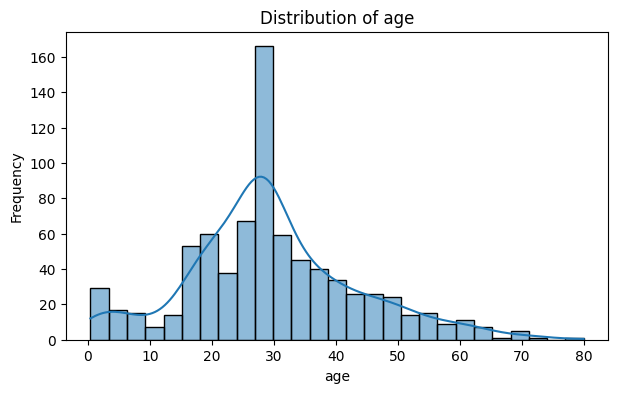

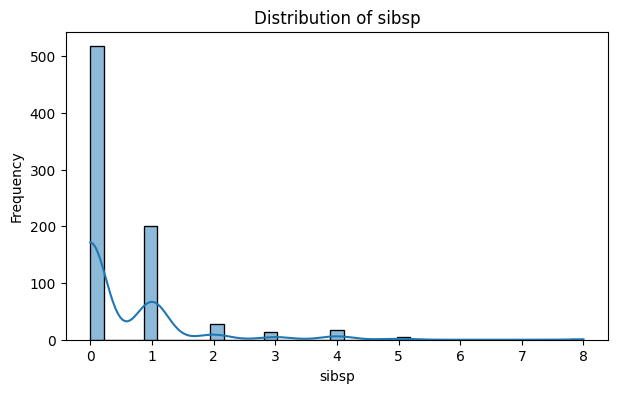

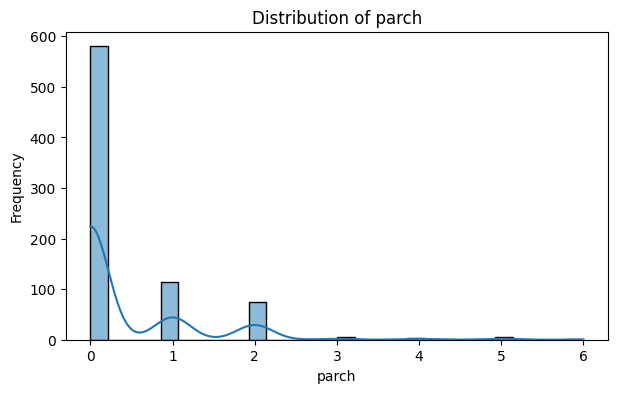

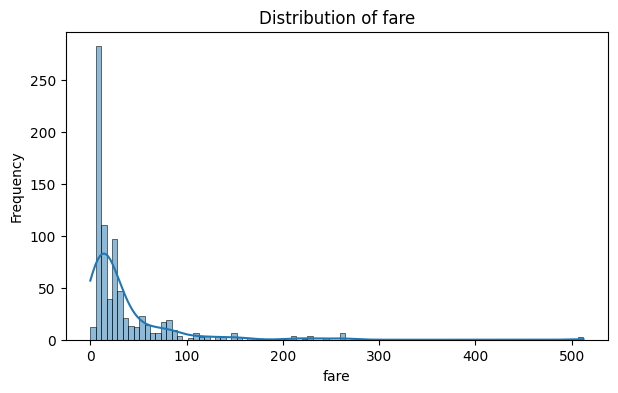

In [19]:
import matplotlib.pyplot as plt

numeric_features = ["age", "sibsp", "parch", "fare"]

# Calculate skewness
print(df_clean[numeric_features].skew())

for column in numeric_features:
    plt.figure(figsize=(7, 4))
    sns.histplot(df_clean[column], kde=True)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

In [22]:
df_transformed = df_clean.copy()

# Apply log transformation
df_transformed["fare_log"] = np.log1p(
    df_transformed["fare"]
)

df_transformed["sibsp_log"] = np.log1p(
    df_transformed["sibsp"]
)

df_transformed["parch_log"] = np.log1p(
    df_transformed["parch"]
)

- Why log1p()?

log1p(x) calculates:

log(1+x)

It is safer than simply using:

np.log(x)

because it can handle zero:

log1p(0) = log(1) = 0

This is important because sibsp and parch can contain zero.

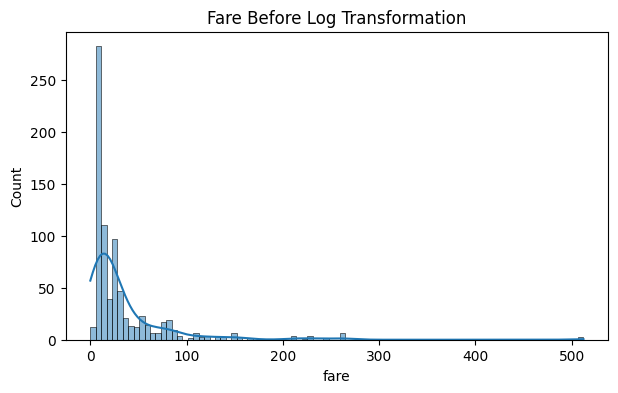

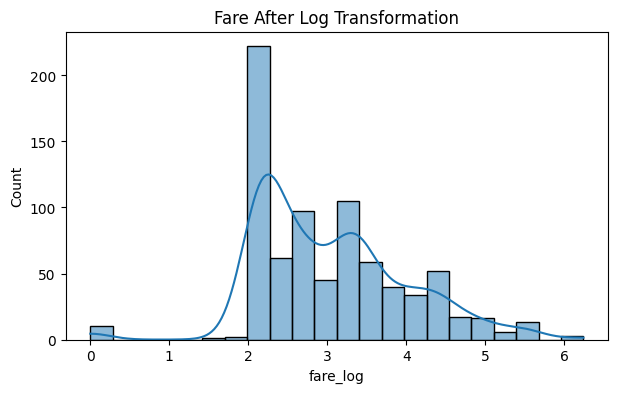

In [23]:
# Before transformation
plt.figure(figsize=(7, 4))
sns.histplot(df_clean["fare"], kde=True)
plt.title("Fare Before Log Transformation")
plt.show()

# After transformation
plt.figure(figsize=(7, 4))
sns.histplot(df_transformed["fare_log"], kde=True)
plt.title("Fare After Log Transformation")
plt.show()

The fare feature is strongly right-skewed because a small number of passengers paid very high fares. A log transformation was applied using log1p(). After transformation, the distribution becomes more symmetrical and the skewness is reduced.

- Part E)

- 1)A data analyst is preparing the Titanic dataset for a machine learning model. Before splitting
the dataset into training and testing sets, the analyst performs missing value imputation and
feature scaling using the entire dataset.


2) Another analyst follows the recommended workflow by first splitting the dataset into training
and testing sets, then fitting the preprocessing methods using only the training dataset before
transforming both datasets.


Answer the following questions:

1. What is the main difference between the two preprocessing workflows?

- Workflow 1 — Incorrect

Entire Dataset
      ↓
Imputation
      ↓
Scaling
      ↓
Train/Test Split

The preprocessing methods are fitted using the entire dataset.


- Workflow 2 — Correct
Entire Dataset
      ↓
Train/Test Split
      ↓
Training Data ──→ Fit preprocessing
                      ↓
Testing Data ──→ Transform only

The preprocessing parameters are learned only from the training data.

2. Which workflow introduces data leakage ?

Answer-

The first workflow introduces data leakage.

Why?

Because information from the test dataset is used while calculating preprocessing parameters.

For example, if we calculate:

mean = entire_dataset.mean()

the mean contains information from both:

Training data
+
Testing data

Therefore, information from the test set has leaked into the training process.

3. Why preprocessing methods should be fitted only on the training dataset?

Answer -

Preprocessing methods such as:

SimpleImputer
StandardScaler
MinMaxScaler
RobustScaler

learn parameters from data.

For example:

StandardScaler

Learns:
mean,
standard deviation

MinMaxScaler

Learns:
minimum,
maximum,

SimpleImputer

Learns:
median,
or
most frequent value

If these parameters are calculated using the test set, the model indirectly receives information about the test data.

This makes the evaluation artificially optimistic.

4. Which workflow would you recommend for building a reliable machine learning
model? Justify your answer.

Answer

The second workflow should be recommended.

The correct process is:

1. Load dataset
       ↓
2. Split into training and testing data
       ↓
3. Fit preprocessing on training data
       ↓
4. Transform training data
       ↓
5. Transform testing data
       ↓
6. Train model
       ↓
7. Evaluate model


- The second workflow is recommended because the preprocessing methods are fitted only using the training dataset. This prevents information from the test dataset from influencing the preprocessing parameters. As a result, the test set remains an unbiased representation of unseen data and provides a more reliable estimate of model performance.